Dean Hickman

Spring 2025

CS 343: Neural Networks

Project 2: Multi-layer Perceptrons

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt

# for preprocessing dataset
import preprocess_data

# Set the color style so that Professor Layton can see your plots
plt.show()
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.rcParams.update({'font.size': 20})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

def plot_cross_entropy_loss(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Training mini-batch')
    plt.ylabel('Loss (cross-entropy)')
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load in data

### a. STL-10

Run your function to load in the preprocessed STL-10 data in the following split:

- 3000 training samples
- 750 test samples
- 1000 validation samples
- 250 samples for development

In [49]:
X_train, y_train, X_test, y_test, X_val, y_val, X_dev, y_dev = preprocess_data.load_stl10(n_train_samps= 3000, n_test_samps = 750, n_valid_samps = 1000, n_dev_samps= 250) 

print(f"X_train has shape {(X_train).shape}")
print(f"X_test has shape {X_test.shape}")
print(f"X_val has shape {X_val.shape}")
print(f"X_dev has shape {X_dev.shape}")

Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)
X_train has shape (3000, 3072)
X_test has shape (750, 3072)
X_val has shape (1000, 3072)
X_dev has shape (250, 3072)


### b. Circle in a square

The circle in a square (CIS) dataset is a simple binary classification dataset that is useful for debugging and visualizing what your MLP is learning. Points with (x, y) coordinates inside a circle have class value of 1, points with coordinates outside the circle have class value of 0. Training on the CIS dataset allows us to answer the question: can the MLP learn to discriminate whether a test point falls inside or outside the circle?

#### Todo

- Download the CIS dataset then run the cell below to load in the CIS train (`cis_train.dat`) and test (`cis_test.dat`) sets as numpy arrays.
- Below, make a scatterplot showing the test set data. Color-code samples based on their class. If everything goes well, you should see a...solid, filled in circle inside unit square :)
    - Make the aspect ratio of your x, y plotting axes equal, otherwiwse you might see an ellipse!

In case you're curious about the data format:
- Like usual, each row is a different sample.
- The x-coordinate feature is the 1st column
- The y-coordinate feature is the 2nd column
- The class label (0 or 1) is in the third column.


In [50]:
val_size = 20

cis_train_path = os.path.join('data', 'cis', 'cis_train.dat')
cis_test_path = os.path.join('data', 'cis', 'cis_test.dat')

cis_train_all = np.loadtxt(cis_train_path, delimiter='\t')

# shuffle the data
s_inds = np.arange(len(cis_train_all))
rng = np.random.default_rng(0)
rng.shuffle(s_inds)

cis_train_all = cis_train_all[s_inds]

cis_train_x = cis_train_all[:, :2]
cis_train_y = cis_train_all[:, 2].astype(int)

cis_val_x = cis_train_x[:val_size]
cis_train_x = cis_train_x[val_size:]
cis_val_y = cis_train_y[:val_size]
cis_train_y = cis_train_y[val_size:]

cis_test_all = np.loadtxt(cis_test_path, delimiter='\t')
cis_test_x = cis_test_all[:, :2]
cis_test_y = cis_test_all[:, 2].astype(int)

print ('CIS Train data shape: ', cis_train_x.shape)
print ('CIS Train labels shape: ', cis_train_y.shape)
print ('CIS Validation data shape: ', cis_val_x.shape)
print ('CIS Validation labels shape: ', cis_val_y.shape)
print ('CIS Test data shape: ', cis_test_x.shape)
print ('CIS Test labels shape: ', cis_test_y.shape)

CIS Train data shape:  (80, 2)
CIS Train labels shape:  (80,)
CIS Validation data shape:  (20, 2)
CIS Validation labels shape:  (20,)
CIS Test data shape:  (10000, 2)
CIS Test labels shape:  (10000,)


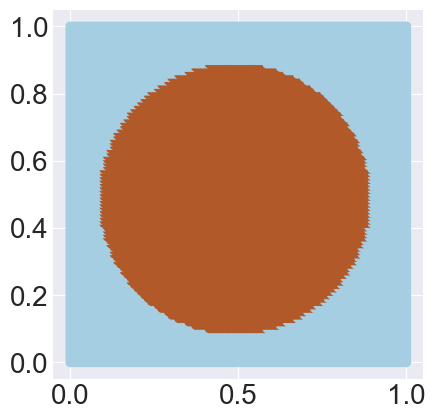

In [51]:
plt.scatter(cis_test_x[:, 0], cis_test_x[:, 1], c = cis_test_y, cmap='Paired')
plt.gca().set_aspect('equal', adjustable='box')

## Task 3: Implement Multilayer Perceptron (MLP) with softmax activation and cross-entropy loss

Now that we've tested the softmax activation function and cross-entropy loss functions in a single-layer net, let's implement the MLP version.

Much of your work on the single layer net will carry over, so go ahead and copy-paste and modify as needed!

#### The structure of our MLP

```
Input layer (X units) ->
Hidden layer (Y units) with Rectified Linear activation (ReLu) ->
Output layer (Z units) with softmax activation
```

### 3a. Implement the following functions in `mlp.py`

- `initialize_wts`
- `accuracy`
- `one_hot`
- `predict`
- `forward`
- `backward`
- `fit`: see note below.

#### Updates to `fit`

Now that you have built and fit several neural networks, let's make a helpful update to the training process: in addition to recording the training loss and accuracy, record the accuracy on the **validation set** after every training epoch. Every `print_every` epochs print out validation accuracy to monitor performance on the validation set. See the `fit` docstring for details.

### 3b. Test key functions with randomly generated data

In [52]:
from mlp import MLP

In [53]:
# Create a dummy net for debugging
num_inputs = 3
num_features = 6
num_hidden_units = 7
num_classes = 5

net = MLP(num_features, num_hidden_units, num_classes)

In [54]:
# Generate random data and classes
rng = np.random.default_rng(0)
test_x = rng.normal(loc=0, scale=100, size=(num_inputs, num_features))
test_y = rng.integers(low=0, high=num_classes-1, size=(num_inputs,))
print(f'Test input shape: {test_x.shape}')
print(f'Test class vector shape: {test_y.shape}')

Test input shape: (3, 6)
Test class vector shape: (3,)


#### Test `initialize_wts`

In [55]:
net.initialize_wts(M=num_features, H=num_hidden_units, C=num_classes, std=0.01, r_seed=0)
print(f'y wt shape is {net.y_wts.shape} and should be (6, 7)')
print(f'y bias shape is {net.y_b.shape} and should be (7,)')
print(f'z wt shape is {net.z_wts.shape} and should be (7, 5)')
print(f'z bias shape is {net.z_b.shape} and should be (5,)')

print(f'1st few y wts are\n{net.y_wts[:,0]}\nand should be\n[ 0.001  0.009 -0.012  0.014 -0.005  0.004]')
print(f'y bias is\n{net.y_b}\nand should be\n[ 0.013  0.008  0.003 -0.003  0.015  0.02   0.018]')
print(f'1st few z wts are\n{net.z_wts[:,0]}\nand should be\n[ 0.013 -0.013 -0.007  0.003 -0.022  0.018  0.02 ]')
print(f'z bias is\n{net.z_b}\nand should be\n[-0.013  0.006  0.006  0.013 -0.008]')

y wt shape is (6, 7) and should be (6, 7)
y bias shape is (7,) and should be (7,)
z wt shape is (7, 5) and should be (7, 5)
z bias shape is (5,) and should be (5,)
1st few y wts are
[ 0.001  0.009 -0.012  0.014 -0.005  0.004]
and should be
[ 0.001  0.009 -0.012  0.014 -0.005  0.004]
y bias is
[ 0.013  0.008  0.003 -0.003  0.015  0.02   0.018]
and should be
[ 0.013  0.008  0.003 -0.003  0.015  0.02   0.018]
1st few z wts are
[ 0.013 -0.013 -0.007  0.003 -0.022  0.018  0.02 ]
and should be
[ 0.013 -0.013 -0.007  0.003 -0.022  0.018  0.02 ]
z bias is
[-0.013  0.006  0.006  0.013 -0.008]
and should be
[-0.013  0.006  0.006  0.013 -0.008]


#### Test the `predict` method

In [56]:
test_y_pred = net.predict(test_x)
print(f'Predicted classes are {test_y_pred} and should be [3 0 3]')

Predicted classes are [3 0 3] and should be [3 0 3]


#### Test the `forward` method focusing on`ReLU`(net act of hidden layer `y`)

In [57]:
_,y_net_act_test,_,_,_ = net.forward(test_x, test_y)

correct_y_act = np.array([[0.   , 0.   , 0.433, 0.38 , 0.841, 0.217, 0.464],
       [0.522, 0.362, 0.201, 0.   , 0.   , 0.   , 2.697],
       [0.202, 1.955, 0.   , 0.   , 0.284, 0.   , 0.   ]])

print(f'Your y activation is\n{y_net_act_test}')
print(f'The correct y activation (ReLU) is\n{correct_y_act}')

Your y activation is
[[0.    0.    0.433 0.38  0.841 0.217 0.464]
 [0.522 0.362 0.201 0.    0.    0.    2.697]
 [0.202 1.955 0.    0.    0.284 0.    0.   ]]
The correct y activation (ReLU) is
[[0.    0.    0.433 0.38  0.841 0.217 0.464]
 [0.522 0.362 0.201 0.    0.    0.    2.697]
 [0.202 1.955 0.    0.    0.284 0.    0.   ]]


#### Test the `forward` method

In [58]:
_,_,_,probs,_ = net.forward(test_x, test_y)

correct_probs = np.array([[0.196, 0.2  , 0.201, 0.207, 0.196],
       [0.208, 0.202, 0.196, 0.201, 0.192],
       [0.192, 0.204, 0.203, 0.206, 0.194]])

print(f'Your z activation (class probabilities) is\n{probs}')
print(f'The correct z activation (class probabilities) is\n{correct_probs}')
print(f'The sums for each row (data sample) are {np.sum(probs, axis=1)}.')
print(f'  You should know what should be :)')

Your z activation (class probabilities) is
[[0.196 0.2   0.201 0.207 0.196]
 [0.208 0.202 0.196 0.201 0.192]
 [0.192 0.204 0.203 0.206 0.194]]
The correct z activation (class probabilities) is
[[0.196 0.2   0.201 0.207 0.196]
 [0.208 0.202 0.196 0.201 0.192]
 [0.192 0.204 0.203 0.206 0.194]]
The sums for each row (data sample) are [1. 1. 1.].
  You should know what should be :)


#### Test the `forward` method, focusing on loss

In [59]:
y_in, y_act ,z_in, z_act, loss = net.forward(test_x, test_y)
correct_loss = 1.6067

print(f'Your average loss is\n{loss:.4f}')
print(f'The correct average loss is approx\n{correct_loss}')

Your average loss is
1.6067
The correct average loss is approx
1.6067


#### Test the `forward` method, focusing on regularization

In [60]:
y_in, y_act ,z_in, z_act, loss = net.forward(test_x, test_y, reg=1000)
correct_loss = 4.8772

print(f'Your regularized average loss is\n{loss:.4f}')
print(f'The correct regularized average loss is approx\n{correct_loss}')

Your regularized average loss is
4.8772
The correct regularized average loss is approx
4.8772


#### Test the `backward` method

In [61]:
y_in, y_act ,z_in, z_act, loss = net.forward(test_x, test_y, reg=0.5)
grads = net.backward(test_x, test_y, y_in, y_act ,z_in, z_act, reg=0.5)

print('Your gradient for y_wts is\n', grads[0])
print('Your gradient for y_b is\n', grads[1])
print('Your gradient for z_wts is\n', grads[2])
print('Your gradient for z_b is\n', grads[3])

Your gradient for y_wts is
 [[ 0.064  0.18   0.126  0.017  0.267 -0.068 -0.139]
 [-0.023 -0.148  0.047 -0.021 -0.071  0.061  0.041]
 [ 0.085  0.367  0.043  0.084  0.53  -0.349 -0.392]
 [ 0.095  0.381 -0.081  0.018  0.129 -0.062 -0.014]
 [ 0.051  0.225 -0.138 -0.072 -0.316  0.299  0.387]
 [ 0.016  0.048  0.059  0.052  0.275 -0.206 -0.235]]
Your gradient for y_b is
 [-0.001 -0.004  0.002  0.001  0.006 -0.006 -0.007]
Your gradient for z_wts is
 [[ 0.056 -0.191  0.042  0.049  0.05 ]
 [ 0.144 -0.613  0.158  0.162  0.144]
 [-0.105 -0.027  0.036  0.052  0.039]
 [-0.1    0.024  0.033  0.033  0.028]
 [-0.218 -0.019  0.079  0.082  0.07 ]
 [-0.049  0.008  0.011  0.02   0.014]
 [ 0.073 -0.685  0.204  0.211  0.198]]
Your gradient for z_b is
 [-0.135 -0.465  0.2    0.205  0.194]


The correct gradients are:

```
Your gradient for y_wts is
 [[ 0.064  0.18   0.126  0.017  0.267 -0.068 -0.139]
 [-0.023 -0.148  0.047 -0.021 -0.071  0.061  0.041]
 [ 0.085  0.367  0.043  0.084  0.53  -0.349 -0.392]
 [ 0.095  0.381 -0.081  0.018  0.129 -0.062 -0.014]
 [ 0.051  0.225 -0.138 -0.072 -0.316  0.299  0.387]
 [ 0.016  0.048  0.059  0.052  0.275 -0.206 -0.235]]
Your gradient for y_b is
 [-0.001 -0.004  0.002  0.001  0.006 -0.006 -0.007]
Your gradient for z_wts is
 [[ 0.056 -0.191  0.042  0.049  0.05 ]
 [ 0.144 -0.613  0.158  0.162  0.144]
 [-0.105 -0.027  0.036  0.052  0.039]
 [-0.1    0.024  0.033  0.033  0.028]
 [-0.218 -0.019  0.079  0.082  0.07 ]
 [-0.049  0.008  0.011  0.02   0.014]
 [ 0.073 -0.685  0.204  0.211  0.198]]
Your gradient for z_b is
 [-0.135 -0.465  0.2    0.205  0.194]
```

#### Test loss over epoch (1 of 2). 

The below code should generate a curve that rapidly drops to 0 (there might be fluctuations and it might not be monotonic and that's ok)

Your `fit` function should show you print-outs showing:
- Loss and validation accuracy 4 times throughout training.
- 100% accuracy on validation set after around 5 epochs of training.
- You are training on 20 epochs.
- There are 20 iterations.
- There is 1 iteration per epoch.

Here is an example print-out from `fit`:

    Starting to train network...There will be 20 epochs and 20 iterations total, 1 iter/epoch.
    Completed Epoch 0/19. Training loss: 3.53. Training acc:   0.00%. Validation acc:   0.00%.
    Completed Epoch 5/19. Training loss: 0.62. Training acc:  66.67%. Validation acc:  66.67%.
    Completed Epoch 10/19. Training loss: 0.44. Training acc: 100.00%. Validation acc: 100.00%.
    Completed Epoch 15/19. Training loss: 0.17. Training acc: 100.00%. Validation acc: 100.00%.
    Finished training!

Starting to train network...There will be 20 epochs and 20 iterations total, 1 iter/epoch.
Completed epoch 0/19. Training loss: 3.12. Training acc: 0.00. Validation acc: 0.00.
Completed epoch 5/19. Training loss: 0.80. Training acc: 0.67. Validation acc: 0.67.
Completed epoch 10/19. Training loss: 0.33. Training acc: 1.00. Validation acc: 1.00.
Completed epoch 15/19. Training loss: 0.18. Training acc: 1.00. Validation acc: 1.00.
Finished training!

Lengths of each output list:
len(loss_hist)=20, len(acc_train)=20, len(acc_valid)=20
Each should be 20.


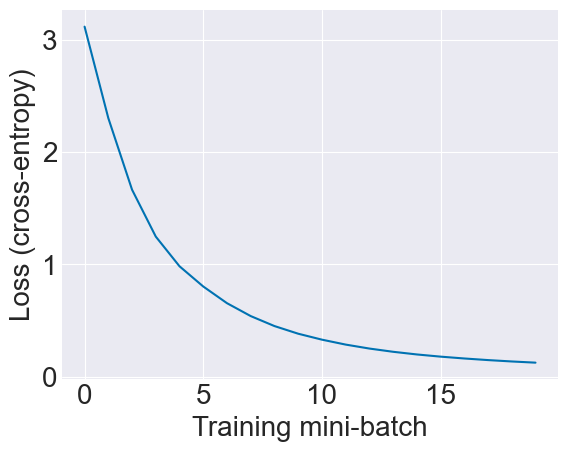

In [62]:
model = MLP(num_features, num_hidden_units, num_classes)
loss_hist, acc_train, acc_valid = model.fit(test_x, test_y, test_x, test_y,
                                          reg=0,
                                          print_every=5,
                                          lr=0.001,
                                          mini_batch_sz=3,
                                          n_epochs=20,
                                          r_seed=0)

print('\nLengths of each output list:')
print(f'{len(loss_hist)=}, {len(acc_train)=}, {len(acc_valid)=}')
print('Each should be 20.')

plot_cross_entropy_loss(loss_hist)

#### Test loss over epoch (2 of 2). 

The below curve should look similar, perhaps a little bumpier.

Your `fit` function should print out:
- Loss and validation accuracy 5 times throughout training.
- 100% accuracy on validation set after around 2 epochs of training.
- You are training on 10 epochs.
- There are 30 iterations.
- There are 3 iterations per epoch.


Starting to train network...There will be 10 epochs and 30 iterations total, 3 iter/epoch.
Completed epoch 0/9. Training loss: 14.29. Training acc: 0.67. Validation acc: 0.67.
Completed epoch 2/9. Training loss: 0.23. Training acc: 1.00. Validation acc: 1.00.
Completed epoch 4/9. Training loss: 0.63. Training acc: 1.00. Validation acc: 1.00.
Completed epoch 6/9. Training loss: 0.07. Training acc: 1.00. Validation acc: 1.00.
Completed epoch 8/9. Training loss: 0.32. Training acc: 1.00. Validation acc: 1.00.
Finished training!

Lengths of each output list:
len(loss_hist)=30, len(acc_train)=10, len(acc_valid)=10
The lengths should be 30, 10, 10.


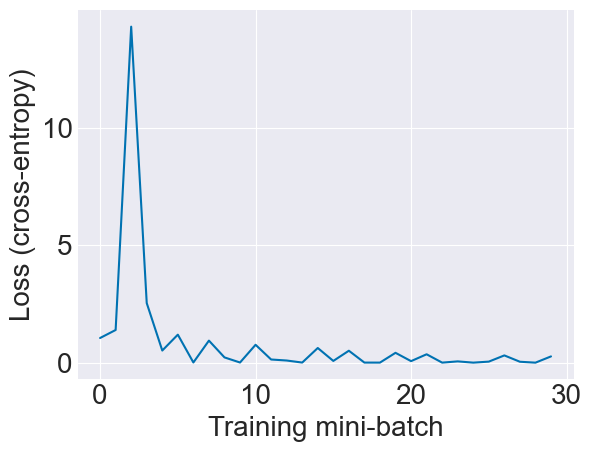

In [63]:
model = MLP(num_features, num_hidden_units, num_classes)
loss_hist, acc_train, acc_valid = model.fit(test_x, test_y, test_x, test_y,
                                          reg=0,
                                          print_every=2,
                                          lr=0.001,
                                          mini_batch_sz=1,
                                          n_epochs=10,
                                          r_seed=2)

print('\nLengths of each output list:')
print(f'{len(loss_hist)=}, {len(acc_train)=}, {len(acc_valid)=}')
print('The lengths should be 30, 10, 10.')

plot_cross_entropy_loss(loss_hist)



### 3c. Test MLP with Circle in Square dataset

Before you run your MLP on the STL-10 dataset, test it out on the simpler CIS dataset.

In cells below:
- Train an MLP using the CIS training and validation sets. Configure the MLP with the following non-default hyperparameters:
    - 50 hidden units
    - Learning rate of `0.5`
    - Mini-batch size of `80`
    - `600` epochs
    - Random seed of `0`
- Plot the loss over training iterations. You should see:
    - A nice drop and plateau in mini-batch training loss (*with a few potentially large fluctuations along the way*).
    - Accuracy on the validation set reach ~85-90%.
- Create a scatter plot of the MLP predictions on the CIS test set. Color-code each sample by its class. Make sure your axis aspect ratios are equal.

In [64]:
num_features = 2
num_hidden_units = 50
num_classes = 2
lr = 0.5
batch_size = 80
epoch = 600
r_seed = 0
model = MLP(num_features, num_hidden_units, num_classes)

loss_hist, acc_train, acc_valid = model.fit(cis_train_x, cis_train_y, cis_val_x, cis_val_y,
                                          reg=0,
                                          print_every=100,
                                          lr=lr,
                                          mini_batch_sz=batch_size,
                                          n_epochs=epoch,
                                          r_seed=0)


Starting to train network...There will be 600 epochs and 600 iterations total, 1 iter/epoch.
Completed epoch 0/599. Training loss: 0.69. Training acc: 0.46. Validation acc: 0.50.
Completed epoch 100/599. Training loss: 0.65. Training acc: 0.64. Validation acc: 0.50.
Completed epoch 200/599. Training loss: 0.50. Training acc: 0.88. Validation acc: 0.85.
Completed epoch 300/599. Training loss: 0.35. Training acc: 0.82. Validation acc: 0.75.
Completed epoch 400/599. Training loss: 0.33. Training acc: 0.76. Validation acc: 0.70.
Completed epoch 500/599. Training loss: 0.14. Training acc: 0.99. Validation acc: 0.90.
Finished training!


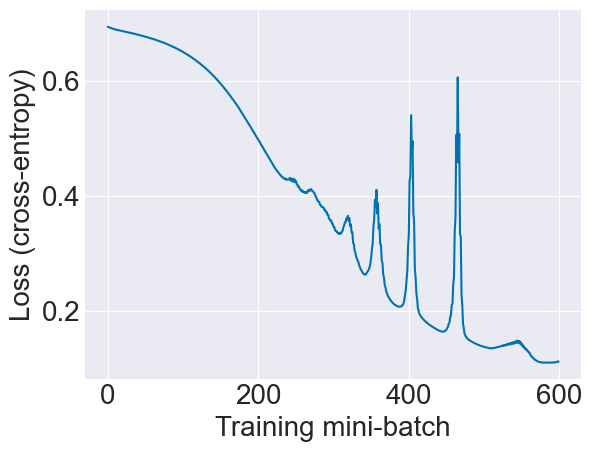

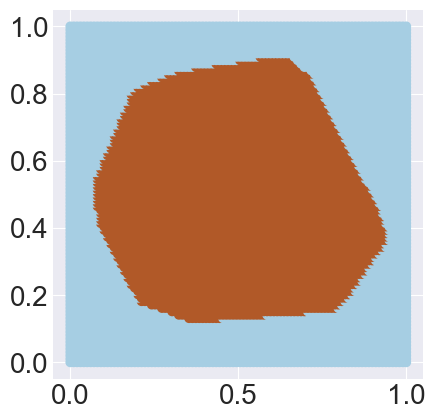

In [65]:
plot_cross_entropy_loss(loss_hist)
plt.scatter(cis_test_x[:, 0], cis_test_x[:, 1], c = model.predict(cis_test_x), cmap='Paired')
plt.gca().set_aspect('equal', adjustable='box')

**Question 6**: How do you interpret the circle-in-square scatterplot? Is the MLP doing a good job? 

**Answer 6**:

The circle is missing its smooth edges which means that the MLP is misclassifying some of the test data. Where I expect to see a proper circle there are some geometric sides that clearly indicate that MLP is not doing the greatest job, however because I can at least see the makings of a circle I wouldn't say that the MLP is a terrible model.

**Question 7**: Play with
- number of hidden units
- number of epochs
- batch size

How does each parameter affect the results?

**Answer 7**:

When I decrease the number of hidden units the validation accuracy increases and the scatterplot takes more of a circular shape. When I mess with the batch size there are mixed effects, certain values decrease or increase the validation accuracy. They also change the area of the "circle" plotted. The more I increase the number of epochs the more that the loss decreases. The figure holds its shape around 600 epochs but the loss vs training iter plot shows that the loss plateaus around 2600. What I conclude is that hidden units help form what I should see, batch_size helps with the extent to which I should see that thing, and epochs help with controlling the loss ensuring that my network is really getting to that global minimum. 

I did this by changing each of these parameters one at a time. Choosing a number higher or lower than the defaults. Then I would decide whether to keep decreasing that given or to increase it depending on what the plots looked like and that data from the printouts.

**Question 8**: Do you think the single-layer net (with softmax) can handle the CIS dataset? Why or why not? (You're invited to try it, maybe as an extension :)

**Answer 8**:

I don't think that a single-layer net (with softmax) can handle the CIS dataset because we need to draw a non-linear boundary to model the complexity the data has. What would happen if we used the single-layer is that we lose our additional non-linear activation functions where the classes are not easily separable by a linear function.

### 3d. Test on STL-10 dataset, plot performance

Train an MLP on the STL-10 training set with the following non-default hyperparameters:
- 50 hidden units
- Learning rate of 0.1
- Regularization strength of 0.001
- Mini-batch size of 500
- 100 epochs
    
Make two plots:
- Plot the training loss (like usual). *Remember: the units are mini-batches.*
- Plot the training and validation set accuracies (2 curves in one plot — include a legend, title, axis labels, etc.). *Remember: the units are epochs.*

In [66]:
num_features = 3072
num_hidden_units = 50
model = MLP(num_features, num_hidden_units, 10)
loss_hist, acc_train, acc_valid = model.fit(X_train, y_train, X_val, y_val, 
                                            n_epochs=100,
                                            mini_batch_sz=500,
                                            r_seed=0,
                                            lr = 0.1, 
                                            reg = 0.001,
                                            verbose=2, 
                                            print_every=10,
                                            )




Starting to train network...There will be 100 epochs and 600 iterations total, 6 iter/epoch.
Completed epoch 0/99. Training loss: 3.39. Training acc: 0.22. Validation acc: 0.20.
Completed epoch 10/99. Training loss: 2.43. Training acc: 0.42. Validation acc: 0.30.
Completed epoch 20/99. Training loss: 2.29. Training acc: 0.47. Validation acc: 0.31.
Completed epoch 30/99. Training loss: 2.09. Training acc: 0.56. Validation acc: 0.34.
Completed epoch 40/99. Training loss: 1.87. Training acc: 0.61. Validation acc: 0.32.
Completed epoch 50/99. Training loss: 1.52. Training acc: 0.74. Validation acc: 0.35.
Completed epoch 60/99. Training loss: 1.45. Training acc: 0.79. Validation acc: 0.34.
Completed epoch 70/99. Training loss: 1.30. Training acc: 0.86. Validation acc: 0.34.
Completed epoch 80/99. Training loss: 1.07. Training acc: 0.92. Validation acc: 0.34.
Completed epoch 90/99. Training loss: 1.01. Training acc: 0.94. Validation acc: 0.33.
Finished training!


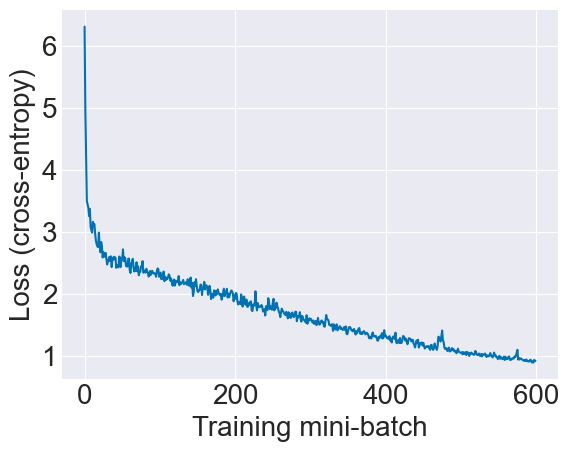

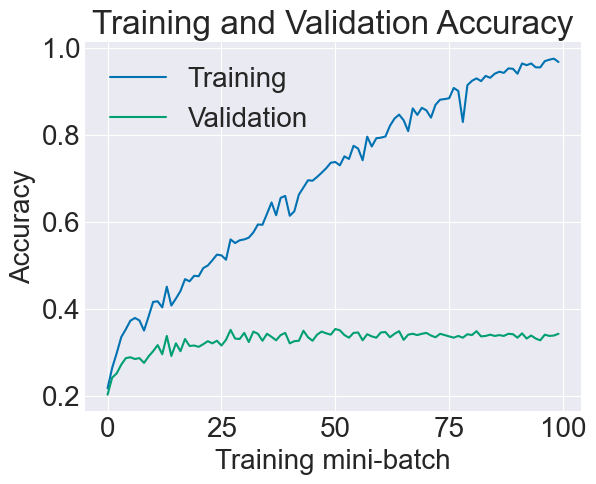

In [67]:
plot_cross_entropy_loss(loss_hist)

plt.plot(acc_train, label='Training')
plt.plot(acc_valid, label='Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Training mini-batch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 3e. Questions

**Question 9**: What do the above loss and training and validation accuracy curves suggest about the quality of the hyperparameters used during training?

**Answer 9:**

It shows that during training our model overfits becuase our hyperparamters are actually very good, but when we use the val set we can see that our hyperparameters are actually not the best if we want the MLP to generalize well.

### 3f. Optimize on STL-10 dataset with random search

To optimize your MLP hyperparameters on STL-10, try a **random search** rather than a grid search. This means that instead of defining preset *values* that each hyperparameter takes on, define *ranges* (min and max values).

Run your search for some $T$ iterations. On each iteration, randomly assign values to each hyperparameter within their valid ranges.

Just like grid search:
- print out the accuracy and parameter values every time a bout of training yields the **best accuracy** on the **STL-10 validation set**. That way, if you need to stop the search prematurely, you know the current best hyperparameter combination.
- make sure your results from the search are reproducible and you can train a net after the search is over and get the same accuracy.

Consider combinations of the following hyperparameters:
- learning rate
- regularization strength
- number of hidden units
- mini-batch size
- number of epochs (try between `1` and `150`). *Reduce the upper limit if your machine is taking too long to train a net with this many epochs.*

**Important note:** Like usual, I am not grading based on how long you search. I want to see that you successfully implemented the random search to find progressively better hyperparameters on STL-10. You should be able to improve upon your softmax net accuracy from last week.

**Tips:**
- Just like with grid search, if you find a cluster of parameters that seems promising, you can revise your search to hone in on that smaller range.
- Turn off print outs from `fit` (adjust `verbose` argument) and only print out things related to your search.
- If you are getting `RuntimeWarning`, your learning rate may be too high.

In [68]:
best_val_acc = 0
tuned_params = None
results = []

learning_rates = np.array([0.1, 0.01])
regularizations = np.array([0.1, 0.01])
hidden_units = np.array([10, 20, 30])
mini_batch_sizes = np.array([100, 250, 500])
num_epochs = np.array([50, 125])

for learning_rate in learning_rates:
    for reg in regularizations:
        for num_hidden_units in hidden_units:
            for batch in mini_batch_sizes:
                for epoch in num_epochs:
                    model = MLP(num_features, num_hidden_units, 10)
                    loss_hist, acc_train, acc_valid = model.fit(X_train, y_train, X_val, y_val, 
                                                    n_epochs= epoch,
                                                    mini_batch_sz= batch,
                                                    r_seed=0,
                                                    lr =learning_rate, 
                                                    reg = reg,
                                                    verbose=0,
                                                    print_every=10, 
                                                    )

                    val_acc = model.accuracy(y_val, model.predict(X_val))
                    results.append((learning_rate, reg, batch, num_hidden_units, val_acc))

                    if val_acc > best_val_acc:
                        best_val_acc = val_acc
                        tuned_params = (learning_rate, reg, batch, num_hidden_units, epoch)
                        print(f"New best -> LR: {learning_rate}, Reg: {reg}, Batch Size: {batch}, Hidden unit: {num_hidden_units}, Epochs: {epoch}, Val Acc: {val_acc:.2f}")



print(f"Learning rate: {tuned_params[0]} \n Regularization: {tuned_params[1]} \n Batch size: {tuned_params[2]} \n Hidden unit: {tuned_params[3]} \n Epochs: {tuned_params[4]} \n Validation Accuracy: {best_val_acc:.2f}")
print("\n--- All Tried Configurations ---")



New best -> LR: 0.1, Reg: 0.1, Batch Size: 100, Hidden unit: 10, Epochs: 50, Val Acc: 0.34
New best -> LR: 0.1, Reg: 0.1, Batch Size: 100, Hidden unit: 10, Epochs: 125, Val Acc: 0.38
New best -> LR: 0.1, Reg: 0.1, Batch Size: 250, Hidden unit: 10, Epochs: 50, Val Acc: 0.39
New best -> LR: 0.1, Reg: 0.1, Batch Size: 250, Hidden unit: 10, Epochs: 125, Val Acc: 0.39
New best -> LR: 0.1, Reg: 0.1, Batch Size: 100, Hidden unit: 20, Epochs: 50, Val Acc: 0.39
New best -> LR: 0.1, Reg: 0.1, Batch Size: 250, Hidden unit: 20, Epochs: 125, Val Acc: 0.41
Learning rate: 0.1 
 Regularization: 0.1 
 Batch size: 250 
 Hidden unit: 20 
 Epochs: 125 
 Validation Accuracy: 0.41

--- All Tried Configurations ---


### 3g. Plot STL-10 results with best hyperparameters

Train an MLP with the best hyperparameters that you found from your parameter search and create two plots:
- Training STL-10 loss curve
- Training and validation set STL-10 accuracy curves. **Place the test set accuracy in the plot title.**

Starting to train network...There will be 125 epochs and 1500 iterations total, 12 iter/epoch.
Completed epoch 0/124. Training loss: 26.68. Training acc: 0.27. Validation acc: 0.25.
Completed epoch 100/124. Training loss: 1.69. Training acc: 0.56. Validation acc: 0.38.
Finished training!


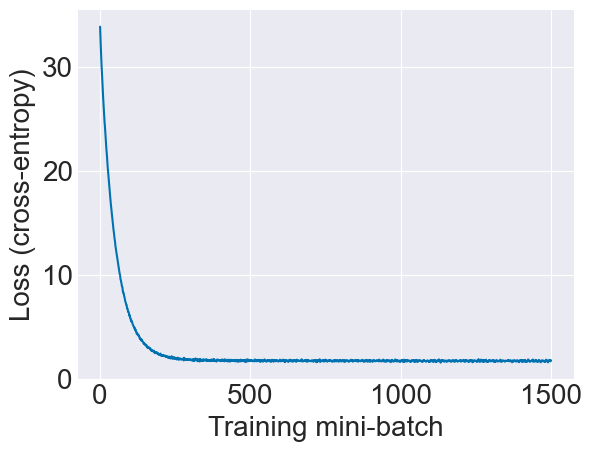

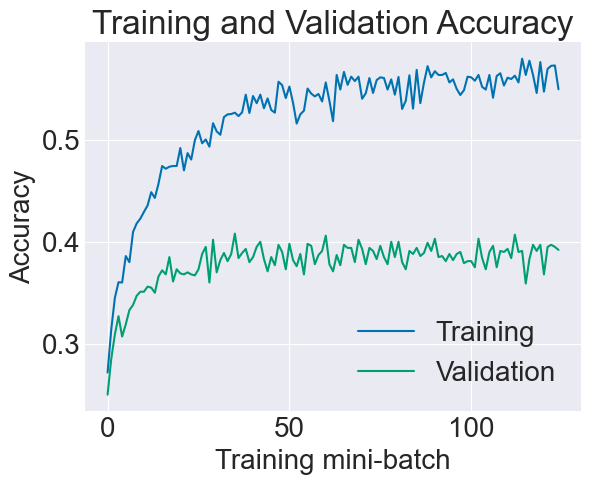

In [73]:
best_net = MLP(num_features, tuned_params[3], 10)
loss_hist, acc_train, acc_valid = best_net.fit(X_train, y_train, X_val, y_val,
    n_epochs= tuned_params[4],
    mini_batch_sz= tuned_params[2],
    r_seed=0,
    lr=tuned_params[0],
    reg=tuned_params[1])

plot_cross_entropy_loss(loss_hist)

test_accuracy = best_net.accuracy(y_test, best_net.predict(X_test))

plt.plot(acc_train, label='Training')
plt.plot(acc_valid, label='Validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Training mini-batch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 3i. Visualize learned weights

Run the `plot_weights` function to generate a grid visualization of them.

You should see structure in the weights if your network is performing well. If you have a large number of hidden units, some may not be "used" so a subset of the weights may resemble "noise".

In [75]:
best_y_wts = best_net.get_y_wts()
best_y_wts = best_y_wts.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)

In [76]:
def plot_weights(wts, maxRows=25, verbose=0):
    # limit height of figure by number of neurons
    grid_sz = int(maxRows)
    grid_sz = np.minimum(grid_sz, int(np.sqrt(len(wts))))

    if verbose > 0:
        print(f'Showing {grid_sz} rows')

    plt.figure(figsize=(20,20))
    for x in range(grid_sz):
        for y in range(grid_sz):
            lin_ind = np.ravel_multi_index((x, y), dims=(grid_sz, grid_sz))
            plt.subplot(grid_sz, grid_sz, lin_ind+1)
            currImg = wts[lin_ind]
            low, high = np.min(currImg), np.max(currImg)
            currImg = 255*(currImg - low) / (high - low)
            currImg = currImg.astype('uint8')
            plt.imshow(currImg)
            plt.gca().axis('off')
    plt.subplots_adjust(wspace=0.01, hspace=0.01)
    plt.show()

Showing 4 rows


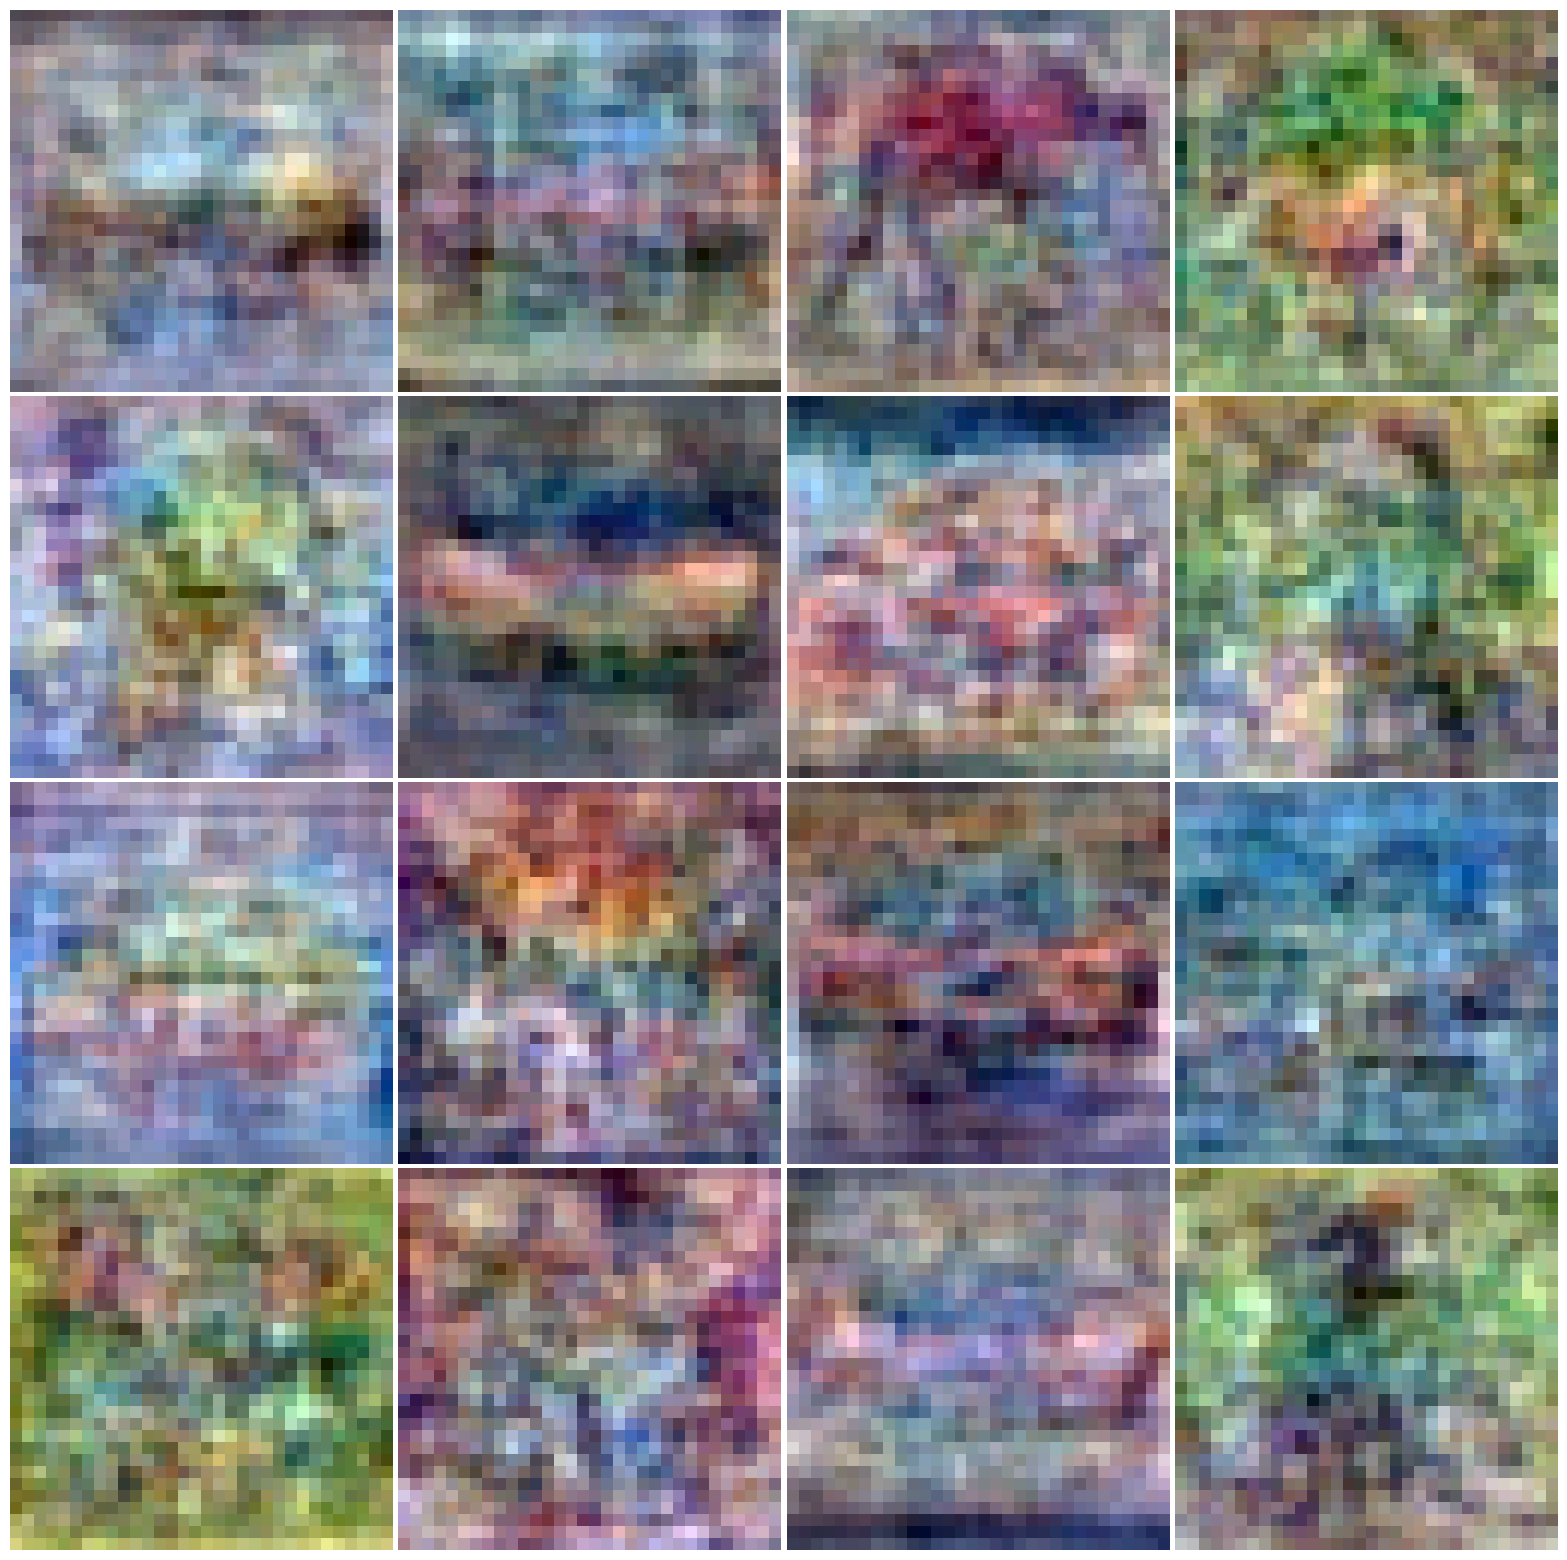

In [72]:
plot_weights(best_y_wts, verbose=1)